# Capítulo 7 — Clasificación: predecir categorías

En los capítulos anteriores organizamos variables, separamos entrenamiento y prueba, y construimos flujos de preprocesamiento. Ahora nos concentraremos en una tarea concreta: asignar cada caso a una categoría.

También veremos, de manera inicial, cómo algunos clasificadores devuelven probabilidades estimadas y cómo una frontera de decisión ayuda a visualizar sus decisiones. El clasificador se utilizará como una caja negra: nos interesa interpretar sus salidas, no estudiar todavía cómo construye sus reglas internas.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- reconocer una variable objetivo categórica;
- distinguir clasificación binaria y multiclase;
- entrenar un primer clasificador sobre datos separados;
- diferenciar etiquetas predichas y probabilidades estimadas;
- observar cómo un umbral convierte probabilidades en clases;
- interpretar una frontera de decisión en un espacio de dos variables;
- describir las predicciones con prudencia.

## 1. Importar las herramientas

Continuaremos con el dataset Wine. Para construir el clasificador usaremos un árbol de decisión pequeño. El algoritmo se presenta únicamente como herramienta operativa y no estudiaremos todavía su funcionamiento interno.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

## 2. Cargar un problema multiclase

Cada fila del dataset representa una muestra de vino y contiene mediciones de su composición química. La variable objetivo original identifica uno de tres cultivares.

In [21]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["cultivar"] = pd.Series(wine.target).map({
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2",
})

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,Cultivar 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,Cultivar 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,Cultivar 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,Cultivar 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,Cultivar 0


La columna `cultivar` es categórica. Sus valores no representan cantidades: son nombres de clases. Veamos cuántos ejemplos hay de cada una.

In [22]:
df["cultivar"].value_counts().sort_index()

,count
cultivar,
Cultivar 0,59
Cultivar 1,71
Cultivar 2,48


Como existen tres categorías posibles, la tarea original es una clasificación multiclase. Más adelante retomaremos estas tres clases; primero construiremos una versión binaria que resulte fácil de visualizar.

## 3. Formular una clasificación binaria

Plantearemos la pregunta: **¿la muestra pertenece al Cultivar 0 o pertenece a otro cultivar?**

Usaremos solo `alcohol` y `color_intensity` como variables de entrada. Limitar el ejemplo a dos variables nos permitirá representar cada muestra como un punto y dibujar la región donde el modelo predice cada clase.

In [23]:
X = df[["alcohol", "color_intensity"]]

y_binaria = df["cultivar"].apply(
    lambda clase: "Cultivar 0" if clase == "Cultivar 0" else "Otros"
)

y_binaria.value_counts()

,count
cultivar,
Otros,119
Cultivar 0,59


La nueva variable objetivo tiene dos clases: 59 muestras de `Cultivar 0` y 119 agrupadas como `Otros`. Aunque una clase aparezca más que la otra, ambas conservan suficientes ejemplos para este ejercicio.

Agrupar clases cambia la pregunta del proyecto. Ya no intentamos distinguir los tres cultivares: solo queremos reconocer uno frente al resto.

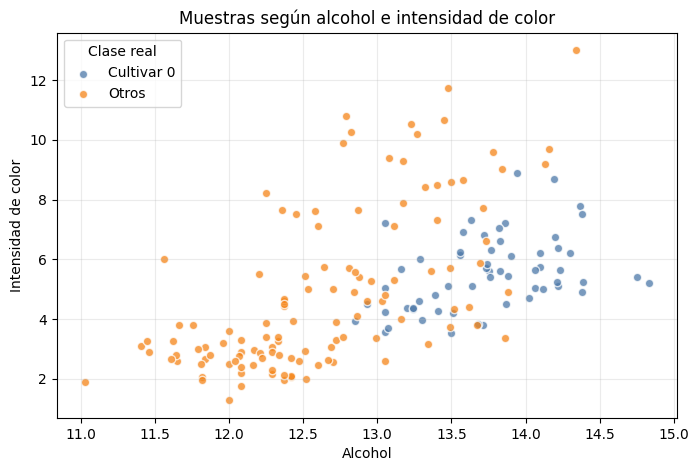

In [24]:
plt.figure(figsize=(8, 5))

colores = {"Cultivar 0": "#4C78A8", "Otros": "#F58518"}

for clase in ["Cultivar 0", "Otros"]:
    mascara = y_binaria == clase
    plt.scatter(
        X.loc[mascara, "alcohol"],
        X.loc[mascara, "color_intensity"],
        label=clase,
        color=colores[clase],
        alpha=0.75,
        edgecolor="white"
    )

plt.title("Muestras según alcohol e intensidad de color")
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")
plt.grid(alpha=0.25)
plt.legend(title="Clase real")
plt.show()

Las clases ocupan regiones diferentes, pero no están separadas perfectamente. Hay zonas donde los puntos se acercan o se mezclan. Esto anticipa una idea importante: clasificar no siempre consiste en descubrir una división evidente y sin errores.

## 4. Separar entrenamiento y prueba

Aplicaremos lo aprendido anteriormente: reservaremos el 25% de las muestras y conservaremos la proporción de las clases mediante estratificación.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binaria,
    test_size=0.25,
    random_state=42,
    stratify=y_binaria
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")
print("\nClases en entrenamiento:")
print(y_train.value_counts())
print("\nClases en prueba:")
print(y_test.value_counts())

Entrenamiento: (133, 2)
Prueba:        (45, 2)

Clases en entrenamiento:
cultivar
Otros         89
Cultivar 0    44
Name: count, dtype: int64

Clases en prueba:
cultivar
Otros         30
Cultivar 0    15
Name: count, dtype: int64


El conjunto de entrenamiento contiene 133 muestras y el de prueba, 45. Ambos conservan ejemplos de `Cultivar 0` y `Otros` en proporciones cercanas a las del dataset completo.

## 5. Entrenar un primer clasificador

Crearemos un árbol de decisión con profundidad limitada. Los parámetros controlan parte de su complejidad, pero no los analizaremos en este capítulo. Lo importante es reconocer la interfaz común de `scikit-learn`: crear el objeto y entrenarlo con `.fit(X_train, y_train)`.

In [26]:
clasificador = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

clasificador.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)

La salida confirma que el clasificador quedó ajustado. Durante ese proceso observó las dos variables de entrada y las etiquetas conocidas del conjunto de entrenamiento.

Que el código se haya ejecutado correctamente no demuestra que el clasificador sea bueno. Para eso necesitaremos evaluar sus predicciones con criterios apropiados.

## 6. Obtener etiquetas predichas

Ahora entregaremos al modelo las variables de entrada reservadas en `X_test`. La función `.predict()` devuelve una etiqueta para cada muestra.

In [27]:
etiquetas_predichas = clasificador.predict(X_test)

etiquetas_predichas[:10]

array(['Otros', 'Otros', 'Otros', 'Cultivar 0', 'Cultivar 0',
       'Cultivar 0', 'Otros', 'Cultivar 0', 'Otros', 'Otros'],
      dtype=object)

Cada elemento es una categoría predicha. No representa una cantidad ni una probabilidad: es la decisión final del clasificador para esa muestra.

Podemos organizar las primeras predicciones junto con las variables de entrada y las clases reales.

In [28]:
comparacion = X_test.head(10).copy()
comparacion["clase_real"] = y_test.head(10)
comparacion["clase_predicha"] = etiquetas_predichas[:10]

comparacion

,alcohol,color_intensity,clase_real,clase_predicha
130,12.86,4.10,Otros,Otros
94,11.62,3.25,Otros,Otros
136,12.25,3.85,Otros,Otros
42,13.88,5.43,Cultivar 0,Cultivar 0
20,14.06,5.65,Cultivar 0,Cultivar 0
62,13.67,3.80,Otros,Cultivar 0
108,12.22,2.70,Otros,Otros
7,14.06,5.05,Cultivar 0,Cultivar 0
102,12.34,2.80,Otros,Otros
60,12.33,3.27,Otros,Otros


La tabla permite revisar casos individuales. Algunas filas pueden coincidir y otras no. En este punto no resumiremos el rendimiento mediante una métrica: el objetivo es comprender qué significa producir una etiqueta de clasificación.

## 7. Obtener probabilidades estimadas

Muchos clasificadores también ofrecen `.predict_proba()`. Esta función devuelve una estimación para cada clase posible. Primero debemos consultar el orden de las clases del modelo.

In [29]:
print("Orden de las clases:", clasificador.classes_)

probabilidades = clasificador.predict_proba(X_test)
probabilidades[:5]

Orden de las clases: ['Cultivar 0' 'Otros']


array([[0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.68292683, 0.31707317],
       [1.        , 0.        ]])

Cada fila contiene dos valores porque el problema es binario. La primera columna corresponde a `Cultivar 0` y la segunda a `Otros`, siguiendo el orden mostrado por `classes_`.

Las dos probabilidades de una misma fila suman 1. Organicemos una tabla más legible.

In [30]:
tabla_probabilidades = pd.DataFrame(
    probabilidades,
    columns=[f"prob_{clase}" for clase in clasificador.classes_],
    index=X_test.index
)

tabla_probabilidades["suma"] = tabla_probabilidades.sum(axis=1)
tabla_probabilidades["etiqueta_predicha"] = etiquetas_predichas

tabla_probabilidades.head(10).round(3)

,prob_Cultivar 0,prob_Otros,suma,etiqueta_predicha
130,0.000,1.000,1.0,Otros
94,0.000,1.000,1.0,Otros
136,0.000,1.000,1.0,Otros
42,0.683,0.317,1.0,Cultivar 0
20,1.000,0.000,1.0,Cultivar 0
62,0.683,0.317,1.0,Cultivar 0
108,0.000,1.000,1.0,Otros
7,1.000,0.000,1.0,Cultivar 0
102,0.000,1.000,1.0,Otros
60,0.000,1.000,1.0,Otros


La etiqueta predicha coincide con la clase que tiene la probabilidad estimada más alta. Un caso cercano a 0,5 expresa una decisión menos marcada que otro cercano a 0 o 1.

Estas probabilidades son estimaciones producidas por este modelo a partir de estos datos. No deben interpretarse automáticamente como certezas ni como probabilidades perfectamente calibradas para el mundo real.

## 8. Convertir probabilidades en clases mediante un umbral

Tomaremos la probabilidad estimada de `Cultivar 0`. Con un umbral de 0,5, clasificaremos como `Cultivar 0` los casos que alcancen o superen ese valor. Después repetiremos la decisión con un umbral más exigente de 0,7.

In [31]:
indice_cultivar_0 = list(clasificador.classes_).index("Cultivar 0")
prob_cultivar_0 = probabilidades[:, indice_cultivar_0]

prediccion_umbral_05 = np.where(
    prob_cultivar_0 >= 0.5,
    "Cultivar 0",
    "Otros"
)

prediccion_umbral_07 = np.where(
    prob_cultivar_0 >= 0.7,
    "Cultivar 0",
    "Otros"
)

comparacion_umbrales = pd.DataFrame({
    "umbral": [0.5, 0.7],
    "predichas_como_Cultivar_0": [
        (prediccion_umbral_05 == "Cultivar 0").sum(),
        (prediccion_umbral_07 == "Cultivar 0").sum(),
    ],
    "predichas_como_Otros": [
        (prediccion_umbral_05 == "Otros").sum(),
        (prediccion_umbral_07 == "Otros").sum(),
    ],
})

comparacion_umbrales

,umbral,predichas_como_Cultivar_0,predichas_como_Otros
0,0.5,17,28
1,0.7,6,39


En esta ejecución, con el umbral 0,5 se clasifican 17 muestras como `Cultivar 0`. Al elevarlo a 0,7, solo 6 alcanzan la condición.

Un umbral más alto exige una señal más fuerte para asignar la clase de interés. Elegirlo correctamente depende del problema y del costo de los distintos errores; no debe hacerse para obtener un resultado más conveniente.

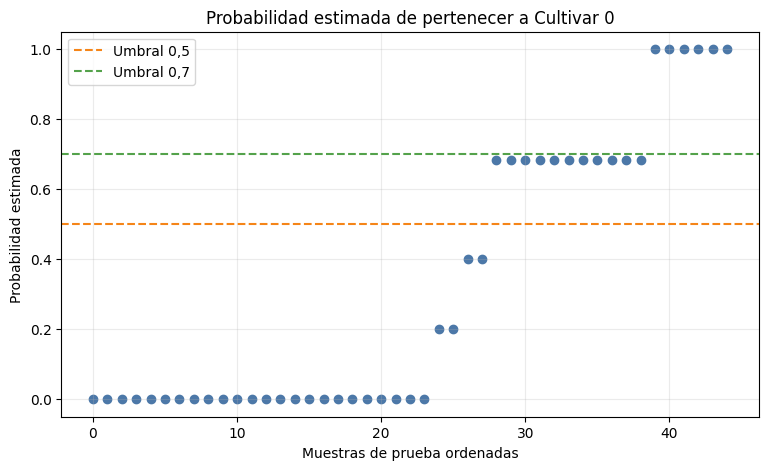

In [32]:
orden_probabilidades = np.argsort(prob_cultivar_0)

plt.figure(figsize=(9, 5))
plt.scatter(
    range(len(prob_cultivar_0)),
    prob_cultivar_0[orden_probabilidades],
    color="#4C78A8"
)
plt.axhline(0.5, color="#F58518", linestyle="--", label="Umbral 0,5")
plt.axhline(0.7, color="#54A24B", linestyle="--", label="Umbral 0,7")
plt.title("Probabilidad estimada de pertenecer a Cultivar 0")
plt.xlabel("Muestras de prueba ordenadas")
plt.ylabel("Probabilidad estimada")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

El gráfico muestra cómo el umbral divide las muestras en dos decisiones. Los puntos por encima de la línea elegida se clasifican como `Cultivar 0`; los demás, como `Otros`.

## 9. Visualizar la frontera de decisión

Como usamos solo dos variables, podemos colorear el plano según la clase que el modelo predeciría en cada posición. El límite entre regiones será la frontera de decisión.

In [33]:
alcohol_min, alcohol_max = X["alcohol"].min() - 0.3, X["alcohol"].max() + 0.3
color_min, color_max = X["color_intensity"].min() - 0.5, X["color_intensity"].max() + 0.5

malla_alcohol, malla_color = np.meshgrid(
    np.linspace(alcohol_min, alcohol_max, 300),
    np.linspace(color_min, color_max, 300)
)

puntos_malla = pd.DataFrame({
    "alcohol": malla_alcohol.ravel(),
    "color_intensity": malla_color.ravel(),
})

clases_malla = clasificador.predict(puntos_malla)
regiones = pd.Series(clases_malla).map({"Cultivar 0": 0, "Otros": 1}).to_numpy()
regiones = regiones.reshape(malla_alcohol.shape)

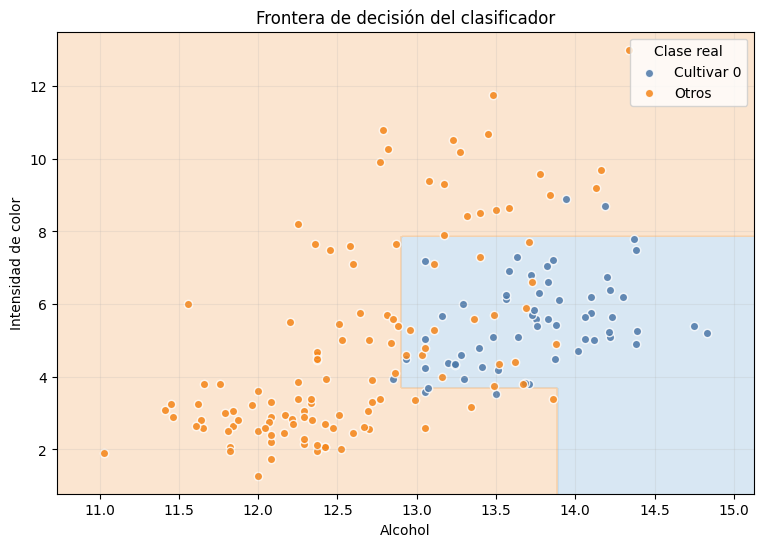

In [34]:
plt.figure(figsize=(9, 6))

mapa_fondo = ListedColormap(["#B9D5EA", "#F8D1AA"])
plt.contourf(
    malla_alcohol,
    malla_color,
    regiones,
    alpha=0.55,
    cmap=mapa_fondo
)

for clase in ["Cultivar 0", "Otros"]:
    mascara = y_binaria == clase
    plt.scatter(
        X.loc[mascara, "alcohol"],
        X.loc[mascara, "color_intensity"],
        label=clase,
        color=colores[clase],
        edgecolor="white",
        alpha=0.85
    )

plt.title("Frontera de decisión del clasificador")
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")
plt.grid(alpha=0.2)
plt.legend(title="Clase real")
plt.show()

El fondo azul representa la región donde el modelo predice `Cultivar 0`; el fondo naranja, donde predice `Otros`. El cambio de color marca la frontera de decisión.

Algunos puntos reales quedan dentro de la región asociada con la otra clase. La frontera no separa los datos perfectamente. Además, representa solamente este modelo entrenado con estas dos variables: otro clasificador o nuevas variables producirían una frontera distinta.

## 10. Clasificar casos nuevos

Crearemos tres muestras hipotéticas dentro de los rangos observados. El clasificador devolverá una etiqueta y una probabilidad para cada clase.

In [35]:
muestras_nuevas = pd.DataFrame({
    "alcohol": [12.2, 13.1, 14.0],
    "color_intensity": [2.5, 5.0, 8.0],
})

etiquetas_nuevas = clasificador.predict(muestras_nuevas)
probabilidades_nuevas = clasificador.predict_proba(muestras_nuevas)

resultado_nuevas = muestras_nuevas.copy()
resultado_nuevas["clase_predicha"] = etiquetas_nuevas

for posicion, clase in enumerate(clasificador.classes_):
    resultado_nuevas[f"prob_{clase}"] = probabilidades_nuevas[:, posicion]

resultado_nuevas.round(3)

,alcohol,color_intensity,clase_predicha,prob_Cultivar 0,prob_Otros
0,12.2,2.5,Otros,0.000,1.000
1,13.1,5.0,Cultivar 0,0.683,0.317
2,14.0,8.0,Otros,0.200,0.800


Cada caso recibe una clase y dos probabilidades complementarias. El resultado depende exclusivamente de `alcohol`, `color_intensity` y la frontera aprendida.

Estas muestras son hipotéticas y el modelo utilizó solo una parte de las variables disponibles. Las predicciones sirven para comprender el mecanismo, no para identificar vinos reales de manera confiable.

## 11. Volver al problema multiclase

En el dataset original existen tres cultivares. Podemos usar las mismas dos variables y el mismo tipo de clasificador para producir una categoría entre tres opciones.## 11. Volver al problema multiclase

En el dataset original existen tres cultivares. Podemos usar las mismas dos variables y el mismo tipo de clasificador para producir una categoría entre tres opciones.

No estamos comparando cuál de los dos planteos es “mejor”. Son preguntas distintas: una distingue `Cultivar 0` frente al resto, y la otra intenta elegir entre los tres cultivares originales.

In [36]:
y_multiclase = df["cultivar"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X,
    y_multiclase,
    test_size=0.25,
    random_state=42,
    stratify=y_multiclase
)

clasificador_multiclase = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

clasificador_multiclase.fit(X_train_multi, y_train_multi)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)

Ahora el clasificador aprendió a elegir entre tres etiquetas. Consultemos las probabilidades de las primeras muestras de prueba.

In [37]:
probabilidades_multi = clasificador_multiclase.predict_proba(X_test_multi.head(5))
etiquetas_multi = clasificador_multiclase.predict(X_test_multi.head(5))

tabla_multi = pd.DataFrame(
    probabilidades_multi,
    columns=[f"prob_{clase}" for clase in clasificador_multiclase.classes_],
    index=X_test_multi.head(5).index
)

tabla_multi["suma"] = tabla_multi.sum(axis=1)
tabla_multi["clase_predicha"] = etiquetas_multi

tabla_multi.round(3)

,prob_Cultivar 0,prob_Cultivar 1,prob_Cultivar 2,suma,clase_predicha
35,0.714,0.036,0.250,1.0,Cultivar 0
93,0.000,1.000,0.000,1.0,Cultivar 1
7,0.952,0.000,0.048,1.0,Cultivar 0
28,0.952,0.000,0.048,1.0,Cultivar 0
87,0.000,1.000,0.000,1.0,Cultivar 1


Cada fila contiene ahora tres probabilidades que suman 1. La etiqueta final corresponde a la clase con el valor más alto.

La lógica general es la misma que en clasificación binaria, pero existen más decisiones posibles y también más formas de confundir una clase con otra.

## Actividad breve

Modificá los valores de `muestra_actividad` dentro de los rangos observados. Podés guiarte por los rangos aproximados del gráfico anterior: valores de alcohol entre 11 y 15, y de intensidad de color entre 1 y 13.

Antes de ejecutar, ubicá mentalmente el punto en el gráfico de la frontera y anticipá qué clase binaria podría recibir.

In [38]:
muestra_actividad = pd.DataFrame({
    "alcohol": [13.5],
    "color_intensity": [4.5],
})

prediccion_actividad = clasificador.predict(muestra_actividad)[0]
probabilidad_actividad = clasificador.predict_proba(muestra_actividad)[0]

print("Clase predicha:", prediccion_actividad)
for clase, probabilidad in zip(clasificador.classes_, probabilidad_actividad):
    print(f"Probabilidad de {clase}: {probabilidad:.3f}")

Clase predicha: Cultivar 0
Probabilidad de Cultivar 0: 0.683
Probabilidad de Otros: 0.317


Si movés el punto dentro del plano, la probabilidad puede cambiar o mantenerse. Cuando atraviese una frontera aprendida por el clasificador, también cambiará la etiqueta predicha.

## Cierre del cuaderno

En este cuaderno construimos un primer clasificador centrado en la interpretación de sus salidas. Partimos de un problema multiclase y formulamos una versión binaria para distinguir `Cultivar 0` de `Otros`.

Vimos que `.predict()` devuelve etiquetas y que `.predict_proba()` produce estimaciones para cada clase. También comprobamos que un umbral transforma probabilidades en decisiones y que modificarlo cambia las etiquetas sin volver a entrenar el modelo.

La frontera de decisión permitió visualizar las regiones donde el clasificador elige cada categoría. Esa frontera no es una verdad absoluta: depende del modelo, de las variables y de los datos utilizados. En los próximos capítulos estudiaremos clasificadores concretos y comprenderemos por qué construyen fronteras diferentes.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Qué diferencia hay entre predecir una cantidad y predecir una categoría?
2. ¿Cómo cambió el problema al agrupar `Cultivar 1` y `Cultivar 2` dentro de `Otros`?
3. ¿Qué diferencia hay entre una etiqueta predicha y una probabilidad estimada?
4. ¿Por qué las probabilidades de todas las clases suman 1 para cada caso?
5. ¿Qué efecto tuvo aumentar el umbral de 0,5 a 0,7?
6. ¿Por qué una frontera de decisión no debe interpretarse como una separación verdadera y universal?